# CEAL Inference — v16A (5-class, no geo features)

Cross-dataset evaluation of Nichol's GazeNet v16A on the CEAL dataset.

- **Model:** GazeNet (3 image streams, no geo features)
- **Classes:** 5 (Straight, Up, Down, Left, Right)
- **Checkpoint:** `best_gazenet_model_v16A.pth`
- **Baseline to beat:** iTracker at 39% accuracy
- **CEAL crops:** Tighter eye crops (15% expansion) via `ceal_recrop_eyes.ipynb`

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import time

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

Device: mps


In [2]:
# ============================================================
# PATHS
# ============================================================

ARTIFACTS_DIR  = Path("/Volumes/Crucial X10/210/data/ceal_itracker_artifacts")
MANIFEST_CSV   = ARTIFACTS_DIR / "manifest.csv"
CHECKPOINT     = Path("/Volumes/Crucial X10/210/checkpoints/best_gazenet_model_v16A.pth")

for name, path in [('Artifacts', ARTIFACTS_DIR), ('Manifest', MANIFEST_CSV), ('Checkpoint', CHECKPOINT)]:
    print(f"  {name}: {'OK' if path.exists() else 'MISSING'} — {path}")

  Artifacts: OK — /Volumes/Crucial X10/210/data/ceal_itracker_artifacts
  Manifest: OK — /Volumes/Crucial X10/210/data/ceal_itracker_artifacts/manifest.csv
  Checkpoint: OK — /Volumes/Crucial X10/210/checkpoints/best_gazenet_model_v16A.pth


# Model Definition

In [3]:
# ============================================================
# GazeNet (v16A) — 3 image streams, no geo features
# Copied verbatim from v16A_ckr.ipynb for checkpoint compatibility
# ============================================================

class GazeNet(nn.Module):
    def __init__(self, num_classes=5):
        super(GazeNet, self).__init__()

        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(128*6*6*2 + 256*3*3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face):
        left_flat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_flat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_flat  = self.face_cnn(face).view(face.size(0), -1)
        combined = torch.cat([left_flat, right_flat, face_flat], dim=1)
        return self.fc(combined)

print("GazeNet defined")

GazeNet defined


# Load Data

In [4]:
# ============================================================
# LOAD MANIFEST
# ============================================================

manifest = pd.read_csv(MANIFEST_CSV)
df = manifest[manifest['status'] == 'ok'].copy()
print(f"Manifest: {len(df)} samples, {df['subject'].nunique()} subjects")

# Verify a sample path exists
sample_path = df.iloc[0]['face_path']
print(f"Sample path: {sample_path}")
print(f"  Exists: {Path(sample_path).exists()}")

Manifest: 23520 samples, 56 subjects
Sample path: /Volumes/Crucial X10/210/data/ceal_itracker_artifacts/0050/0050_2m_-30P_0V_-10H_aug0_face.jpg
  Exists: True


In [5]:
# ============================================================
# CREATE LABELS from gaze degrees
#
# 5-class label map matching v16A training:
#   Straight=0, Up=1, Down=2, Left=3, Right=4
# ============================================================

label_map = {'Straight': 0, 'Up': 1, 'Down': 2, 'Left': 3, 'Right': 4}
idx_to_label = {v: k for k, v in label_map.items()}

def degrees_to_label(gaze_v, gaze_h):
    if gaze_v == 0 and gaze_h == 0:
        return 'Straight'
    if abs(gaze_h) > abs(gaze_v):
        return 'Left' if gaze_h < 0 else 'Right'
    if abs(gaze_v) > abs(gaze_h):
        return 'Down' if gaze_v < 0 else 'Up'
    return 'Left' if gaze_h < 0 else 'Right'

df['label_str'] = df.apply(
    lambda r: degrees_to_label(r['gaze_vertical_deg'], r['gaze_horizontal_deg']), axis=1
)
df['label_idx'] = df['label_str'].map(label_map)

print("Label distribution:")
print(df['label_str'].value_counts())
print(f"\nTotal: {len(df)} samples")

Label distribution:
label_str
Left        7840
Right       7840
Down        3360
Up          3360
Straight    1120
Name: count, dtype: int64

Total: 23520 samples


# Dataset & DataLoader

In [6]:
# ============================================================
# TRANSFORMS — match v16A training preprocessing
#   Eyes:  224×224 → 48×48, normalize(0.5, 0.5)
#   Face:  224×224 → 112×112, normalize(0.5, 0.5)
# ============================================================

eye_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

face_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [7]:
# ============================================================
# CEAL DATASET — v16A (no geo features)
# ============================================================

class CEALDataset(Dataset):
    def __init__(self, dataframe, eye_transform, face_transform):
        self.df = dataframe.reset_index(drop=True)
        self.eye_transform = eye_transform
        self.face_transform = face_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        face      = self.face_transform(Image.open(row['face_path']).convert('RGB'))
        left_eye  = self.eye_transform(Image.open(row['left_path']).convert('RGB'))
        right_eye = self.eye_transform(Image.open(row['right_path']).convert('RGB'))
        label     = torch.tensor(row['label_idx'], dtype=torch.long)
        return {'left_eye': left_eye, 'right_eye': right_eye, 'face': face, 'label': label}

dataset = CEALDataset(df, eye_transform, face_transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Dataset: {len(dataset)} samples, {len(loader)} batches")

Dataset: 23520 samples, 368 batches


In [8]:
# ============================================================
# SMOKE TEST
# ============================================================

batch = next(iter(loader))
print(f"left_eye:  {batch['left_eye'].shape}")
print(f"right_eye: {batch['right_eye'].shape}")
print(f"face:      {batch['face'].shape}")
print(f"label:     {batch['label'].shape}  values: {batch['label'][:8].tolist()}")

left_eye:  torch.Size([64, 3, 48, 48])
right_eye: torch.Size([64, 3, 48, 48])
face:      torch.Size([64, 3, 112, 112])
label:     torch.Size([64])  values: [3, 3, 3, 3, 2, 2, 2, 2]


# Load Model & Run Inference

In [9]:
# ============================================================
# LOAD CHECKPOINT
# ============================================================

model = GazeNet(num_classes=5).to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()

print(f"Loaded v16A — {sum(p.numel() for p in model.parameters()):,} params")
print(f"FC output shape: {model.fc[-1].weight.shape}  (should be [5, 256])")

Loaded v16A — 6,549,637 params
FC output shape: torch.Size([5, 256])  (should be [5, 256])


In [10]:
# ============================================================
# INFERENCE
# ============================================================

all_preds = []
all_labels = []
all_probs = []

start_time = time.time()

with torch.no_grad():
    for batch in loader:
        left_eye  = batch['left_eye'].to(device)
        right_eye = batch['right_eye'].to(device)
        face      = batch['face'].to(device)

        outputs = model(left_eye, right_eye, face)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch['label'].numpy())
        all_probs.extend(probs.cpu().numpy())

elapsed = time.time() - start_time

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

accuracy = 100 * np.mean(all_preds == all_labels)

print(f"{'='*50}")
print(f"v16A on CEAL — Results")
print(f"{'='*50}")
print(f"Samples:    {len(all_preds)}")
print(f"Accuracy:   {accuracy:.2f}%")
print(f"iTracker:   39.00%")
print(f"Delta:      {accuracy - 39.0:+.2f}%")
print(f"Time:       {elapsed:.1f}s ({len(all_preds)/elapsed:.0f} samples/sec)")

v16A on CEAL — Results
Samples:    23520
Accuracy:   7.63%
iTracker:   39.00%
Delta:      -31.37%
Time:       152.6s (154 samples/sec)


# Evaluation

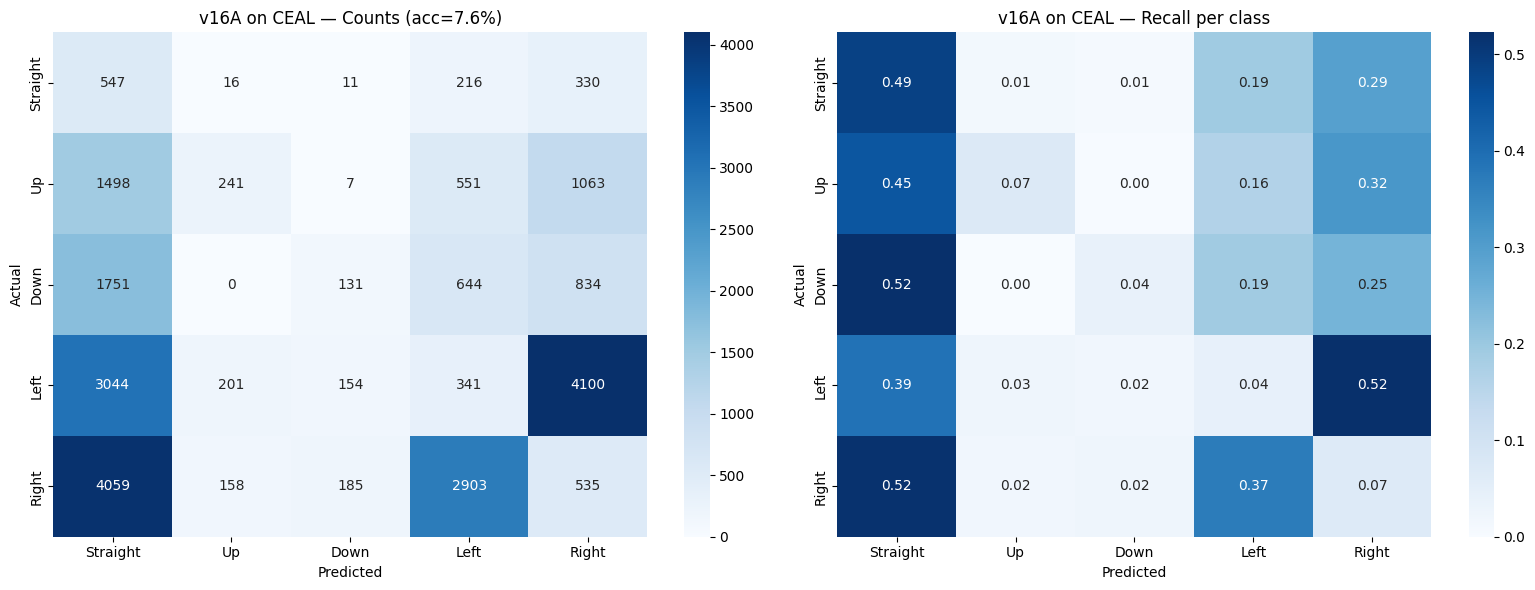

In [11]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

label_names = ['Straight', 'Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'v16A on CEAL — Counts (acc={accuracy:.1f}%)')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'v16A on CEAL — Recall per class')

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(classification_report(all_labels, all_preds, target_names=label_names))

              precision    recall  f1-score   support

    Straight       0.05      0.49      0.09      1120
          Up       0.39      0.07      0.12      3360
        Down       0.27      0.04      0.07      3360
        Left       0.07      0.04      0.05      7840
       Right       0.08      0.07      0.07      7840

    accuracy                           0.08     23520
   macro avg       0.17      0.14      0.08     23520
weighted avg       0.15      0.08      0.07     23520



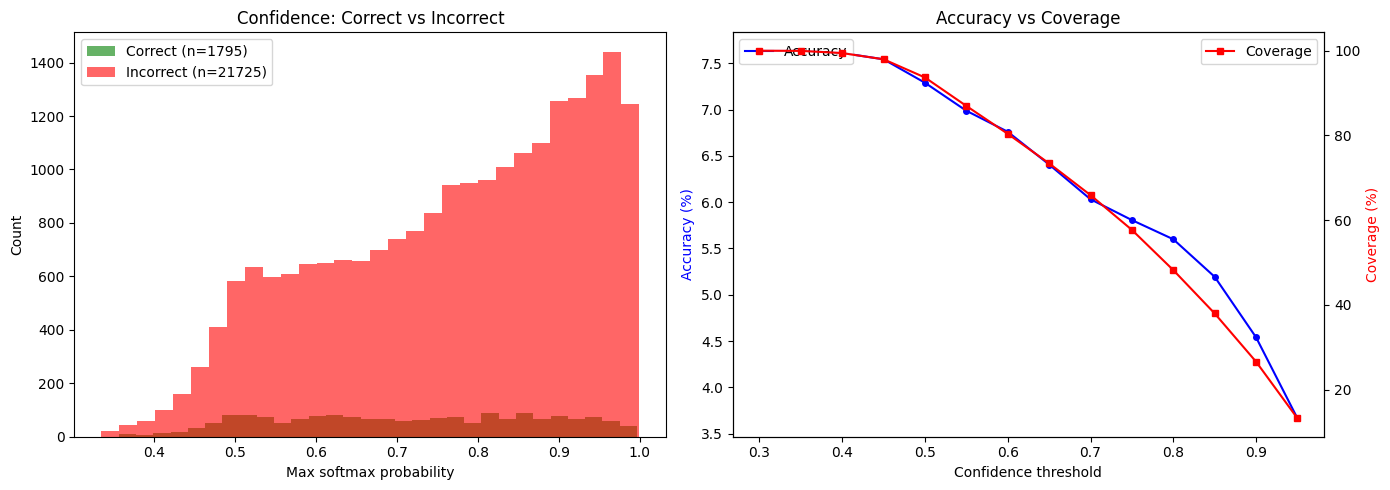

Mean confidence (correct):   0.713
Mean confidence (incorrect): 0.770


In [13]:
# ============================================================
# CONFIDENCE ANALYSIS
# ============================================================

max_probs = all_probs.max(axis=1)
correct_mask = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correct vs incorrect confidence
axes[0].hist(max_probs[correct_mask], bins=30, alpha=0.6,
             label=f'Correct (n={correct_mask.sum()})', color='green')
axes[0].hist(max_probs[~correct_mask], bins=30, alpha=0.6,
             label=f'Incorrect (n={(~correct_mask).sum()})', color='red')
axes[0].set_xlabel('Max softmax probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence: Correct vs Incorrect')
axes[0].legend()

# Accuracy-coverage tradeoff
thresholds = np.arange(0.3, 1.0, 0.05)
accs, covs = [], []
for t in thresholds:
    mask = max_probs >= t
    if mask.sum() > 0:
        accs.append(100 * np.mean(all_preds[mask] == all_labels[mask]))
        covs.append(100 * mask.mean())
    else:
        accs.append(np.nan)
        covs.append(0)

ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(thresholds, accs, 'b-o', markersize=4, label='Accuracy')
ax2.plot(thresholds, covs, 'r-s', markersize=4, label='Coverage')
ax1.set_xlabel('Confidence threshold')
ax1.set_ylabel('Accuracy (%)', color='blue')
ax2.set_ylabel('Coverage (%)', color='red')
ax1.set_title('Accuracy vs Coverage')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"Mean confidence (correct):   {max_probs[correct_mask].mean():.3f}")
print(f"Mean confidence (incorrect): {max_probs[~correct_mask].mean():.3f}")

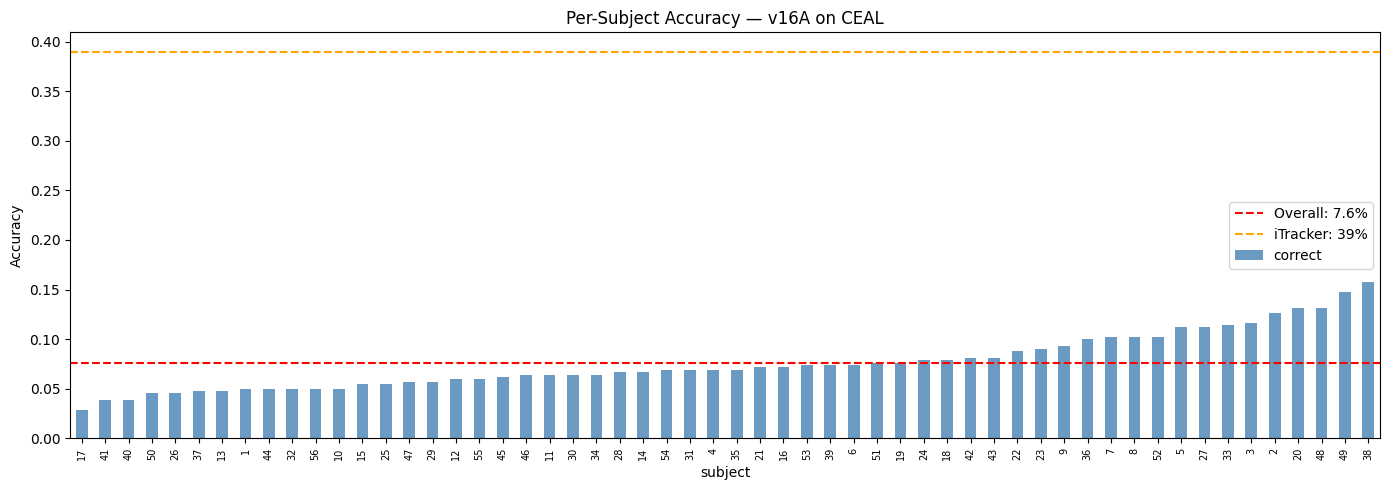

Subject accuracy:
  Min:    2.9% (subject 17)
  Max:    15.7% (subject 38)
  Median: 6.9%
  Std:    2.8%


In [14]:
# ============================================================
# PER-SUBJECT ACCURACY
# ============================================================

df_results = df[['subject', 'label_str', 'orig_filename']].copy()
df_results['pred_idx'] = all_preds
df_results['pred_str'] = [idx_to_label[p] for p in all_preds]
df_results['correct'] = (all_preds == all_labels)
df_results['confidence'] = max_probs

subject_acc = df_results.groupby('subject')['correct'].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
subject_acc.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.axhline(y=accuracy/100, color='red', linestyle='--', label=f'Overall: {accuracy:.1f}%')
ax.axhline(y=0.39, color='orange', linestyle='--', label='iTracker: 39%')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Subject Accuracy — v16A on CEAL')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"Subject accuracy:")
print(f"  Min:    {100*subject_acc.min():.1f}% (subject {subject_acc.idxmin()})")
print(f"  Max:    {100*subject_acc.max():.1f}% (subject {subject_acc.idxmax()})")
print(f"  Median: {100*subject_acc.median():.1f}%")
print(f"  Std:    {100*subject_acc.std():.1f}%")

In [15]:
# ============================================================
# HORIZONTAL vs VERTICAL BREAKDOWN
# ============================================================

for group_name, classes in [('Horizontal (Left/Right)', {'Left', 'Right'}),
                             ('Vertical (Up/Down)', {'Up', 'Down'}),
                             ('Straight', {'Straight'})]:
    mask = df_results['label_str'].isin(classes)
    if mask.sum() > 0:
        acc = 100 * df_results.loc[mask, 'correct'].mean()
        print(f"  {group_name:25s} {acc:.1f}%  (n={mask.sum()})")

  Horizontal (Left/Right)   5.6%  (n=15680)
  Vertical (Up/Down)        5.5%  (n=6720)
  Straight                  48.8%  (n=1120)


In [16]:
# ============================================================
# SAVE PREDICTIONS
# ============================================================

output_path = "/Volumes/Crucial X10/210/eye2voice/CEAL/ceal_predictions_v16A.csv"
df_results.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: /Volumes/Crucial X10/210/eye2voice/CEAL/ceal_predictions_v16A.csv
